# Plutonite model perturbations

In this notebook the user can:

1. Load in the plutonite contact and orientation points (Section 3).
2. Define cross-sections of interest (Section 4).
3. Define a grid search with different levels of sampling for the contact and orientation points and different mean and std levels for the dipping angles for different plutonic blobs (Section 5).
4. Run the perturbation scheme. Warning: this might take long depending on the extent of the gridsearch (Section 6).
5. Visually experiment with the dipping angle (Section 7).

# Loose Ends

- The user needs to adjust the location of the main_results_folder as the perturbation scheme will generate a lot of images that take up a lot of space. This folder should be in a drive, not on Github.
- The perturbation scheme should be improved by adding a functionality that also does forward modelling for gravity and magnetics, rather than saving images. After that a misfit can be calculated between the geophysical data and the forward results and possibly the geology can be compared to the original QGIS geology and combined into one big misfit score. This would essentially be one big forward modelling scheme that can be run during an inversion.

# 1. Packages

In [12]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import geopandas as gpd

from mpl_toolkits.mplot3d import Axes3D

import gempy as gp
import gempy_viewer as gpv
import gempy_engine

from gempy_engine.core.data.stack_relation_type import StackRelationType
import HelperMethods

import threading
import pickle
import os

BASE_DIR = os.getcwd()
data_dir = os.path.abspath(os.path.join(BASE_DIR, '..', '..', 'Data', 'Input_Data'))
geomodel_dir = os.path.abspath(os.path.join(BASE_DIR, '..', '..', 'Data', 'Geological_Models'))

trigger_create_cross_section = True

# 2. Model Parameters

In [13]:
# Model Extent
min_x = -707522
max_x = -677518
min_y =  4528453
max_y =  4549947
max_z =  505
model_depth = -500

# Set the extent of the model
extent=[min_x, max_x, max_y, min_y, model_depth, max_z]

# Set model resolution
nx = ny = nz = 64  # Define grid resolution
resolution = [nx, ny, nz]

# Topography
path_to_topography_reduced = os.path.join(data_dir, 'topo_reduced_sf0.1.tif')

# 3. Load in and Visualise Data

In [14]:
plutonite_orientations_df = pd.read_csv(os.path.join(data_dir, 'Plutonic_Data', 'plutonic_orientations_points.csv'))
plutonite_points_df       = pd.read_csv(os.path.join(data_dir, 'Plutonic_Data', 'plutonic_contact_points.csv'))

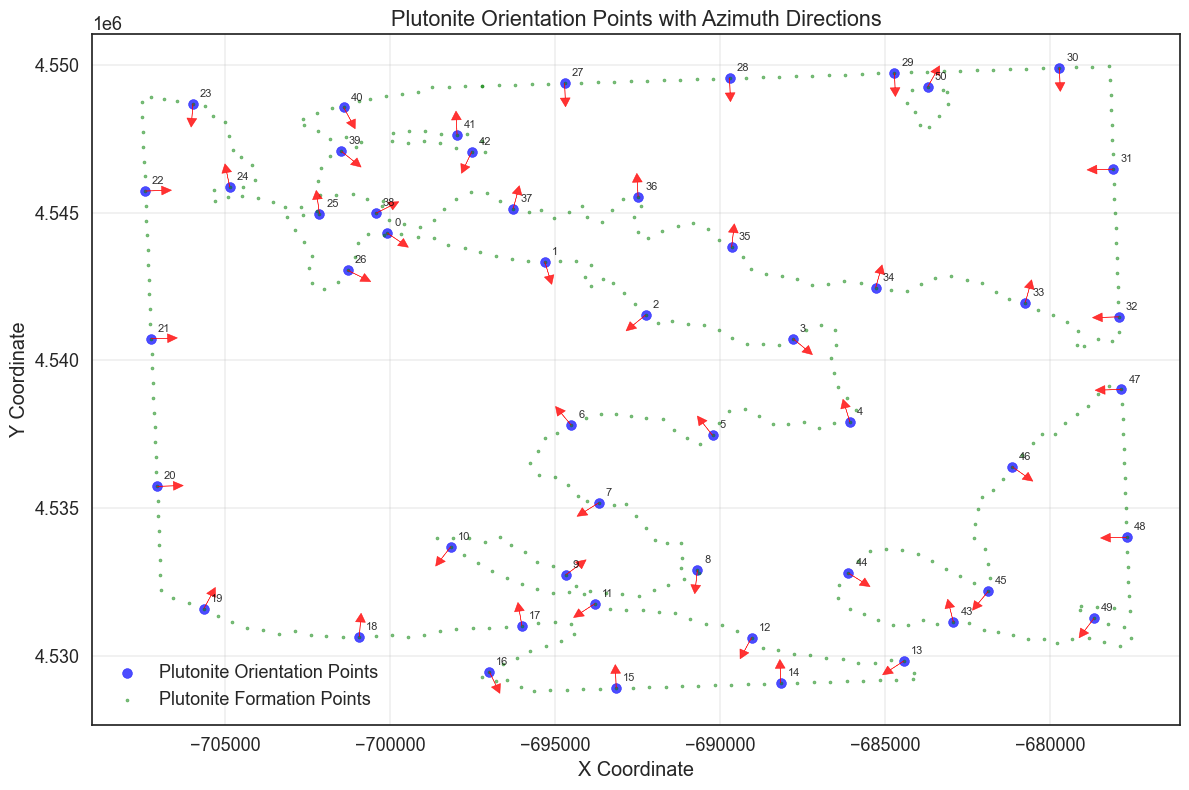

In [15]:
# Visualize plutonite orientations on a map
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the orientation points
scatter = ax.scatter(plutonite_orientations_df['X'], plutonite_orientations_df['Y'], 
                    c='blue', s=50, alpha=0.7, label='Plutonite Orientation Points')

# Also plot the formation points
scatter2 = ax.scatter(plutonite_points_df['X'], plutonite_points_df['Y'], 
                        c='green', s=20, alpha=0.5, label='Plutonite Formation Points', marker='.')

# Add arrows for azimuth directions
for idx, row in plutonite_orientations_df.iterrows():
    # Arrow parameters
    arrow_length = 500  # arrow length in map units
    azimuth_rad = np.deg2rad(row['azimuth'])  # Convert azimuth to radians
    dx = arrow_length * np.sin(azimuth_rad)
    dy = arrow_length * np.cos(azimuth_rad)
    
    # Draw arrow showing strike direction
    ax.arrow(row['X'], row['Y'], dx, dy, 
            head_width=300, head_length=300, fc='red', ec='red', alpha=0.8)

# Add annotations for each point showing its index number
for idx, row in plutonite_orientations_df.iterrows():
    ax.annotate(str(idx), (row['X'], row['Y']), 
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.8, color='black')

ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_title('Plutonite Orientation Points with Azimuth Directions')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Cross Sections of Interest

In [ ]:

section_dict = {'W-E_1': ([-710000,4.54750*1e6], [-675000,4.54750*1e6], [64,64]),
                'W-E_2': ([-710000,4.54000*1e6], [-675000,4.54000*1e6], [64,64]),
                'W-E_3': ([-710000,4.53500*1e6], [-675000,4.53500*1e6], [64,64]),
                'W-E_4': ([-710000,4.5325*1e6], [-675000,4.5325*1e6], [64,64]),
                
                'N-S_1': ([-707500,4.530*1e6], [-707500,4.550*1e6], [64,64]),
                'N-S_2': ([-697500,4.530*1e6], [-697500,4.550*1e6], [64,64]),
                'N-S_3': ([-690000,4.530*1e6], [-690000,4.550*1e6], [64,64]),
                'N-S_4': ([-682500,4.530*1e6], [-682500,4.550*1e6], [64,64])}

# 5. Defining Grid Search Parameters and Dipping Angle Settings

In [27]:
# Make sure level of points > level of orientations and do not go above 0.9
level_of_sampling_points        = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])                          # removing 90%, 80%, 70% etc...
level_of_sampling_orientations  = np.array([0.1, 0.2, 0.3, 0.4, 0.5])                                    # removing 90%, 80%, 70% etc...

In [25]:
# Set mean and std for dip angle perturbations
dip_angle_mean   = {"West Plutonite": 80, "North-East Plutonite": 60, "South Plutonite": 40}
dip_angle_std    = {"Very_random": 5, "Mildly_random": 2.5, "Little_random": 1}
dip_angle_bounds = {"Upper": 90, "Lower": 0} # try negative values to essentially flip the azimuths

# Load the data
plutonite_orientations_df_path = os.path.join(data_dir, 'Plutonic_Data',    'plutonic_orientations_points.csv')
plutonite_points_df_path       = os.path.join(data_dir, 'Plutonic_Data',    'plutonic_contact_points.csv')
topography_path                = os.path.join(data_dir, 'Topographic_Data', 'topo_reduced_sf0.1.tif')

# Where to store the results (can be changed to a OneDrive folder if needed)
main_results_folder = os.path.join(geomodel_dir, 'Plutonite-Perturbed_Models')
os.makedirs(main_results_folder, exist_ok=True)

# 6. Run the perturbation scheme

In [26]:
import sys
from plutonic_perturbations import plutonic_perturbations
del sys.modules['plutonic_perturbations']
from plutonic_perturbations import plutonic_perturbations

plutonic_perturbations(level_of_sampling_points, level_of_sampling_orientations, 
                       section_dict,
                       plutonite_orientations_df_path, plutonite_points_df_path,
                       topography_path,
                       main_results_folder,
                       dip_angle_mean, dip_angle_std,dip_angle_bounds,
                       extent, resolution)

Image already exists for Sampling Points: 0.9, Sampling Orientations: 0.95, Method: Very_random (value: 1), skipping computation.
Image already exists for Sampling Points: 0.9, Sampling Orientations: 0.95, Method: Mildly_random (value: 2), skipping computation.
Image already exists for Sampling Points: 0.9, Sampling Orientations: 0.95, Method: Little_random (value: 3), skipping computation.
Processing: Sampling level (points) = 0.9, Sampling level (orientations) = 0.9, Method = Very_random (value: 1)
Active grids: GridTypes.NONE|TOPOGRAPHY|DENSE
Active grids: GridTypes.NONE|SECTIONS|TOPOGRAPHY|DENSE
Setting Backend To: AvailableBackends.numpy
Chunking done: 42 chunks
Chunking done: 42 chunks


c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_engine\modules\activator\_soft_segment.py:95: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + bt.t.exp(x))


Completed model number 4 of 12
Processing: Sampling level (points) = 0.9, Sampling level (orientations) = 0.9, Method = Mildly_random (value: 2)
Active grids: GridTypes.NONE|TOPOGRAPHY|DENSE
Active grids: GridTypes.NONE|SECTIONS|TOPOGRAPHY|DENSE
Setting Backend To: AvailableBackends.numpy
Chunking done: 42 chunks
Chunking done: 42 chunks


c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_engine\modules\activator\_soft_segment.py:95: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + bt.t.exp(x))


Completed model number 5 of 12
Processing: Sampling level (points) = 0.9, Sampling level (orientations) = 0.9, Method = Little_random (value: 3)
Active grids: GridTypes.NONE|TOPOGRAPHY|DENSE
Active grids: GridTypes.NONE|SECTIONS|TOPOGRAPHY|DENSE
Setting Backend To: AvailableBackends.numpy


KeyboardInterrupt: 

# 7. Experimentation Zone with the Dipping Angles

In [ ]:
plutonite_orientations_df = plutonite_orientations_df.copy()

mean_dip_West_Plutonite       = 80
mean_dip_NorthEast_Plutonite  = 60
mean_dip_South_Plutonite      = 40

std_very_random = 5
std_mildly_random = 2.5
std_little_random = 1

method_name = "mildly random"

In [ ]:

# Assign dip angles based on the chosen method
if method_name == "purely random":
    # Very random
    std = std_very_random
    plutonite_orientations_df.loc[0:26,  'dip']    = np.random.normal(mean_dip_West_Plutonite, std, size=27)     
    plutonite_orientations_df.loc[27:40, 'dip']    = np.random.normal(mean_dip_NorthEast_Plutonite, std, size=14)     
    plutonite_orientations_df.loc[41:42, 'dip']    = np.random.normal(mean_dip_NorthEast_Plutonite, std, size=2)      
    plutonite_orientations_df.loc[43:49, 'dip']    = np.random.normal(mean_dip_South_Plutonite, std, size=7)      
    plutonite_orientations_df.loc[50,    'dip']    = np.random.normal(mean_dip_NorthEast_Plutonite, std, size=1)      
elif method_name == "mildly random":
    # Mildly random
    std = std_mildly_random
    plutonite_orientations_df.loc[0:26,  'dip']    = np.random.normal(mean_dip_West_Plutonite, std, size=27)     
    plutonite_orientations_df.loc[27:40, 'dip']    = np.random.normal(mean_dip_NorthEast_Plutonite, std, size=14)     
    plutonite_orientations_df.loc[41:42, 'dip']    = np.random.normal(mean_dip_NorthEast_Plutonite, std, size=2)      
    plutonite_orientations_df.loc[43:49, 'dip']    = np.random.normal(mean_dip_South_Plutonite, std, size=7)      
    plutonite_orientations_df.loc[50,    'dip']    = np.random.normal(mean_dip_NorthEast_Plutonite, std, size=1)      
elif method_name == "little random":
    # Little random
    std = std_little_random
    plutonite_orientations_df.loc[0:26,  'dip']    = np.random.normal(mean_dip_West_Plutonite, std, size=27)     
    plutonite_orientations_df.loc[27:40, 'dip']    = np.random.normal(mean_dip_NorthEast_Plutonite, std, size=14)     
    plutonite_orientations_df.loc[41:42, 'dip']    = np.random.normal(mean_dip_NorthEast_Plutonite, std, size=2)      
    plutonite_orientations_df.loc[43:49, 'dip']    = np.random.normal(mean_dip_South_Plutonite, std, size=7)      
    plutonite_orientations_df.loc[50,    'dip']    = np.random.normal(mean_dip_NorthEast_Plutonite, std, size=1)      


# Clip the values to ensure they're between 0 and 90
plutonite_orientations_df['dip'] = np.clip(plutonite_orientations_df['dip'], 0, 90)

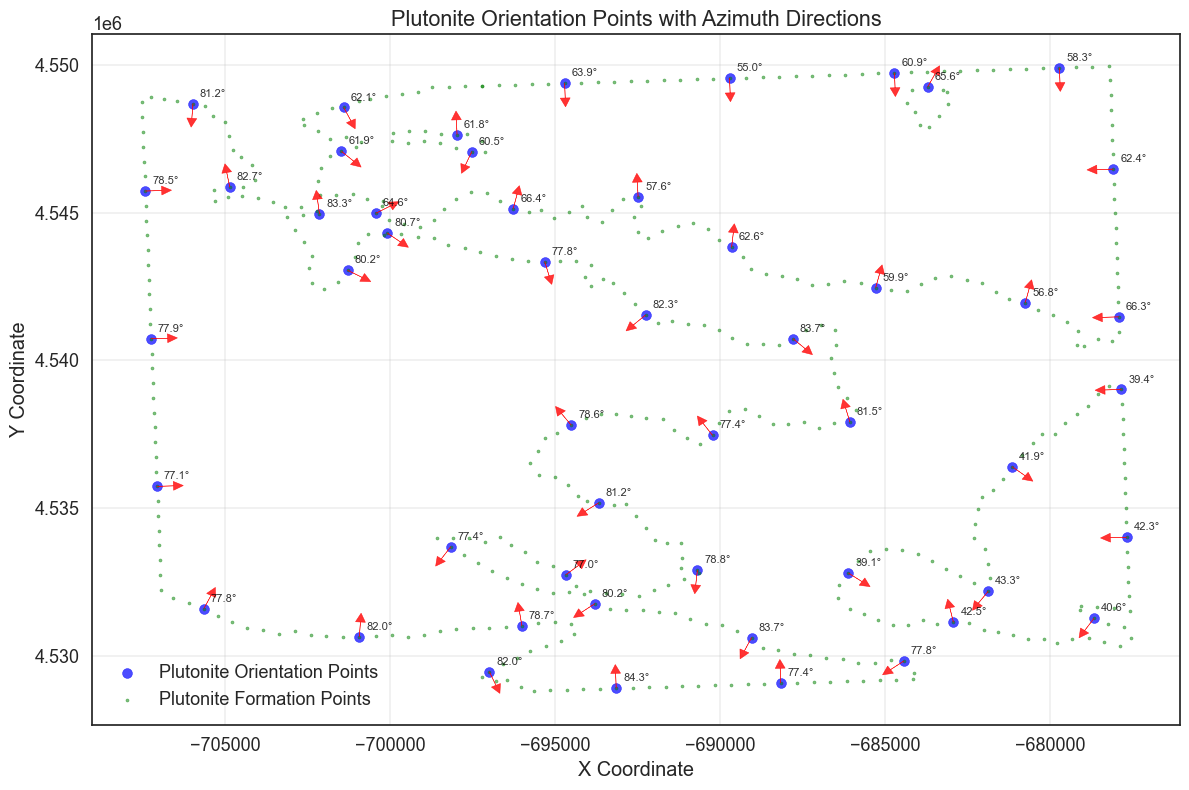

In [ ]:

# Visualize plutonite orientations on a map
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the orientation points
scatter = ax.scatter(plutonite_orientations_df['X'], plutonite_orientations_df['Y'], 
                    c='blue', s=50, alpha=0.7, label='Plutonite Orientation Points')

# Also plot the formation points
scatter2 = ax.scatter(plutonite_points_df['X'], plutonite_points_df['Y'], 
                        c='green', s=20, alpha=0.5, label='Plutonite Formation Points', marker='.')

# Add arrows for azimuth directions
for idx, row in plutonite_orientations_df.iterrows():
    # Arrow parameters
    arrow_length = 500  # arrow length in map units
    azimuth_rad = np.deg2rad(row['azimuth'])  # Convert azimuth to radians
    dx = arrow_length * np.sin(azimuth_rad)
    dy = arrow_length * np.cos(azimuth_rad)
    
    # Draw arrow showing strike direction
    ax.arrow(row['X'], row['Y'], dx, dy, 
            head_width=300, head_length=300, fc='red', ec='red', alpha=0.8)

# Add annotations for each point showing its dip angle
for idx, row in plutonite_orientations_df.iterrows():
    ax.annotate(f"{row['dip']:.1f}°", (row['X'], row['Y']), 
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.8, color='black')

ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_title('Plutonite Orientation Points with Azimuth Directions')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()